# Section 1: Problem Framing

This pipeline helps Harbored Hope connect donation activity to resident outcomes for donor-facing storytelling. The core business problem is that donors want concrete evidence that their money is helping, but operations data is stored across separate systems: donations, allocations, safehouses, and resident outcomes. There is no direct foreign key from a donation to an individual resident outcome, so impact must be assembled through transparent aggregation.

This work matters to three groups. Donors care because clear impact communication increases trust and repeat giving. Program directors care because they need defensible reporting for funders and board updates. Marketing and fundraising teams care because they need reliable, specific narratives for donation pages, receipts, and campaigns. Donor retention is a top concern, and tangible, verifiable impact statements support retention.

This notebook is primarily **explanatory** with a lightweight predictive component. The explanatory model asks whether higher safehouse-month funding is associated with stronger outcomes; results may be weak, and that is an honest finding. The predictive component is not a sophisticated forecasting system; it uses historical allocation patterns to estimate what a new donation could support. We explicitly avoid causal claims because many confounders (case mix, staffing quality, intervention design, regional context) sit between funding and outcomes.

In [1]:
%matplotlib inline

import warnings
from pathlib import Path
from datetime import datetime
import pickle

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

DATA_DIR = Path("")
MODEL_PATH = Path("donation_impact_pipeline.sav")
PROGRAM_AREAS = ["Education", "Wellbeing", "Operations", "Transport", "Maintenance", "Outreach"]

# Section 2: Data Acquisition, Preparation & Exploration

This section does most of the pipeline work: loading data, profiling distributions, documenting joins, engineering analytical tables, and visualizing funding/outcome relationships.

## Join Map (Documented)

1. `donations` -> `donation_allocations` on `donation_id` to map each donation into one or more allocations.
2. `donation_allocations` -> `safehouses` on `safehouse_id` to add location/capacity context.
3. `donation_allocations` -> `safehouse_monthly_metrics` on `safehouse_id` + temporal alignment:
   - allocation month `M` joins to metrics in `M` (same month) and `M+1` (one-month lag),
   - because outcomes often lag funding; both versions are retained for analysis.
4. `safehouse context` -> `residents` on `safehouse_id` (aggregated only) for resident counts and case mix.
5. `residents` -> `education_records` on `resident_id` + month alignment to aggregate education outcomes by safehouse-month.
6. `residents` -> `health_wellbeing_records` on `resident_id` + month alignment to aggregate health outcomes by safehouse-month.
7. `donations` -> `in_kind_donation_items` on `donation_id` for item-level in-kind story details.
8. `donations` -> `supporters` on `supporter_id` for donor segmentation context (PII is not exposed in outputs).

We also build quarterly rollups because monthly data is noisy for small safehouses.

In [2]:
# Load all required CSVs with date parsing

donations = pd.read_csv(DATA_DIR / "donations.csv", parse_dates=["donation_date"])
allocations = pd.read_csv(DATA_DIR / "donation_allocations.csv", parse_dates=["allocation_date"])
supporters = pd.read_csv(DATA_DIR / "supporters.csv", parse_dates=["created_at", "first_donation_date"])
in_kind_items = pd.read_csv(DATA_DIR / "in_kind_donation_items.csv")
safehouses = pd.read_csv(DATA_DIR / "safehouses.csv", parse_dates=["open_date"])
safehouse_metrics = pd.read_csv(DATA_DIR / "safehouse_monthly_metrics.csv", parse_dates=["month_start", "month_end"])
residents = pd.read_csv(DATA_DIR / "residents.csv", parse_dates=["date_of_birth", "date_of_admission", "date_enrolled", "date_closed", "created_at"])
edu = pd.read_csv(DATA_DIR / "education_records.csv", parse_dates=["record_date"])
health = pd.read_csv(DATA_DIR / "health_wellbeing_records.csv", parse_dates=["record_date"])

frames = {
    "donations": donations,
    "donation_allocations": allocations,
    "supporters": supporters,
    "in_kind_donation_items": in_kind_items,
    "safehouses": safehouses,
    "safehouse_monthly_metrics": safehouse_metrics,
    "residents": residents,
    "education_records": edu,
    "health_wellbeing_records": health,
}

for name, df in frames.items():
    print(f"\n{name}")
    print("shape:", df.shape)
    print(df.dtypes.head(8))
    print("nulls (top 8):")
    print(df.isna().sum().sort_values(ascending=False).head(8))


donations
shape: (420, 13)
donation_id                int64
supporter_id               int64
donation_type             object
donation_date     datetime64[ns]
is_recurring                bool
campaign_name             object
channel_source            object
currency_code             object
dtype: object
nulls (top 8):
referral_post_id    343
campaign_name       275
currency_code       186
amount              186
donation_id           0
supporter_id          0
donation_type         0
donation_date         0
dtype: int64

donation_allocations
shape: (521, 7)
allocation_id                int64
donation_id                  int64
safehouse_id                 int64
program_area                object
amount_allocated           float64
allocation_date     datetime64[ns]
allocation_notes           float64
dtype: object
nulls (top 8):
allocation_notes    521
allocation_id         0
donation_id           0
safehouse_id          0
program_area          0
amount_allocated      0
allocation_date   

In [3]:
# Base profiling tables

print("Donation type counts:\n", donations["donation_type"].value_counts(dropna=False), "\n")
print("Campaign counts:\n", donations["campaign_name"].fillna("Unspecified").value_counts().head(10), "\n")
print("Channel counts:\n", donations["channel_source"].value_counts(dropna=False), "\n")
print("Program area distribution:\n", allocations["program_area"].value_counts(), "\n")
print("Safehouse allocation distribution (top 10):\n", allocations["safehouse_id"].value_counts().head(10))

Donation type counts:
 donation_type
Monetary       234
InKind          98
Time            46
SocialMedia     23
Skills          19
Name: count, dtype: int64 

Campaign counts:
 campaign_name
Unspecified         275
Year-End Hope        60
Summer of Safety     35
Back to School       32
GivingTuesday        18
Name: count, dtype: int64 

Channel counts:
 channel_source
Campaign           119
Event               89
Direct              82
SocialMedia         78
PartnerReferral     52
Name: count, dtype: int64 

Program area distribution:
 program_area
Operations     126
Education      111
Wellbeing      107
Transport       75
Outreach        51
Maintenance     51
Name: count, dtype: int64 

Safehouse allocation distribution (top 10):
 safehouse_id
3    77
4    70
8    60
2    59
1    59
9    57
5    56
6    44
7    39
Name: count, dtype: int64


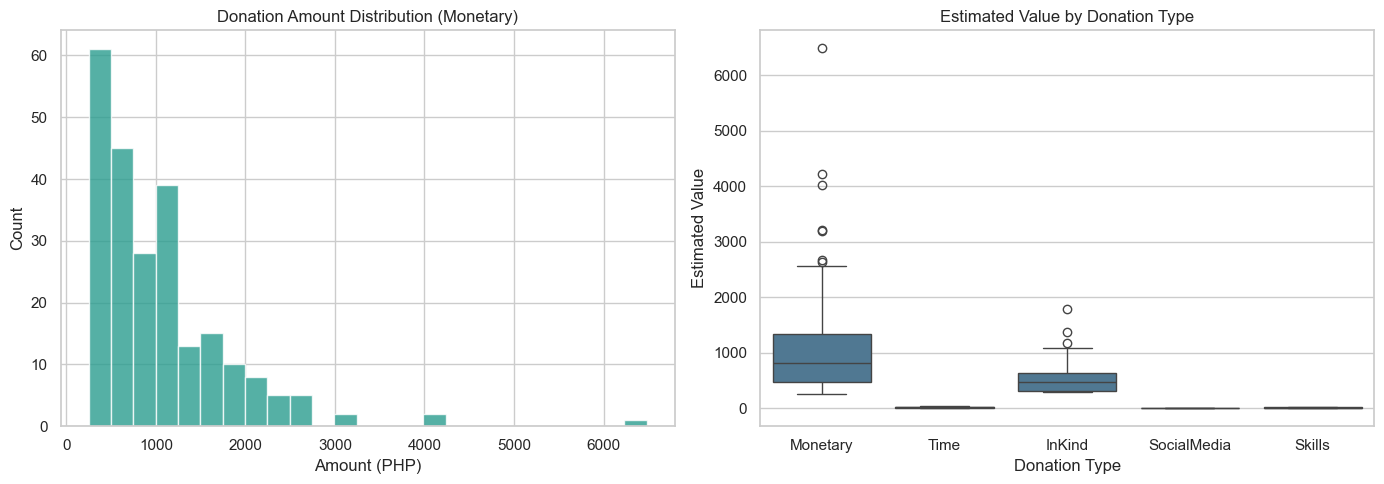

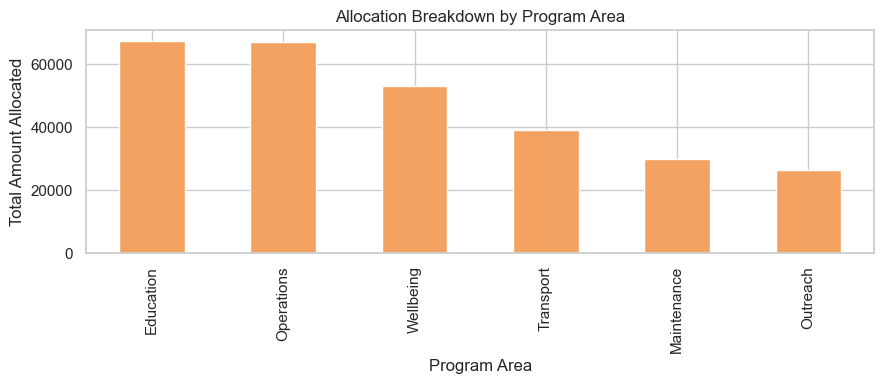

In [4]:
# Key visualizations required in rubric

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
monetary_amounts = donations.loc[donations["donation_type"].eq("Monetary"), "amount"].dropna()
axes[0].hist(monetary_amounts, bins=25, color="#2a9d8f", alpha=0.8)
axes[0].set_title("Donation Amount Distribution (Monetary)")
axes[0].set_xlabel("Amount (PHP)")
axes[0].set_ylabel("Count")

sns.boxplot(data=donations, x="donation_type", y="estimated_value", ax=axes[1], color="#457b9d")
axes[1].set_title("Estimated Value by Donation Type")
axes[1].set_xlabel("Donation Type")
axes[1].set_ylabel("Estimated Value")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
allocations.groupby("program_area")["amount_allocated"].sum().sort_values(ascending=False).plot(kind="bar", color="#f4a261")
plt.title("Allocation Breakdown by Program Area")
plt.xlabel("Program Area")
plt.ylabel("Total Amount Allocated")
plt.tight_layout()
plt.show()

In [5]:
# Prepare month keys for temporal alignment and build base merged allocation table

donations["allocation_month"] = donations["donation_date"].dt.to_period("M").dt.to_timestamp()
allocations["allocation_month"] = allocations["allocation_date"].dt.to_period("M").dt.to_timestamp()
safehouse_metrics["metrics_month"] = safehouse_metrics["month_start"].dt.to_period("M").dt.to_timestamp()

allocation_base = (
    allocations
    .merge(donations[["donation_id", "supporter_id", "donation_type", "campaign_name", "channel_source", "amount", "estimated_value", "donation_date"]], on="donation_id", how="left")
    .merge(safehouses[["safehouse_id", "name", "region", "capacity_girls", "current_occupancy"]], on="safehouse_id", how="left")
)

allocation_base["campaign_name"] = allocation_base["campaign_name"].fillna("Unspecified")
allocation_base["target_month_same"] = allocation_base["allocation_month"]
allocation_base["target_month_lag1"] = (allocation_base["allocation_month"] + pd.offsets.MonthBegin(1)).dt.to_period("M").dt.to_timestamp()

allocation_base.head()

,allocation_id,donation_id,safehouse_id,program_area,amount_allocated,allocation_date,allocation_notes,allocation_month,supporter_id,donation_type,campaign_name,channel_source,amount,estimated_value,donation_date,name,region,capacity_girls,current_occupancy,target_month_same,target_month_lag1
0,1,1,2,Education,717.18,2025-12-31,NaN,2025-12-01,42,Monetary,Unspecified,Campaign,717.18,717.18,2025-12-31,Lighthouse Safehouse 2,Visayas,10,8,2025-12-01,2026-01-01
1,2,2,4,Transport,35.15,2025-12-02,NaN,2025-12-01,25,Time,Year-End Hope,Event,NaN,35.15,2025-12-02,Lighthouse Safehouse 4,Visayas,12,12,2025-12-01,2026-01-01
2,3,3,8,Wellbeing,1074.65,2024-12-02,NaN,2024-12-01,19,Monetary,Unspecified,PartnerReferral,1074.65,1074.65,2024-12-02,Lighthouse Safehouse 8,Visayas,9,7,2024-12-01,2025-01-01
3,4,4,9,Operations,799.86,2023-09-11,NaN,2023-09-01,33,Monetary,Unspecified,PartnerReferral,1230.56,1230.56,2023-09-11,Lighthouse Safehouse 9,Mindanao,6,6,2023-09-01,2023-10-01
4,5,5,8,Operations,1177.41,2023-11-08,NaN,2023-11-01,24,InKind,GivingTuesday,SocialMedia,NaN,1177.41,2023-11-08,Lighthouse Safehouse 8,Visayas,9,7,2023-11-01,2023-12-01


In [6]:
# Table A: safehouse-month funding + outcomes (same month and M+1 lag)

funding_sm = (
    allocations
    .groupby(["safehouse_id", "allocation_month"], as_index=False)
    .agg(total_funding=("amount_allocated", "sum"),
         n_donations=("donation_id", "nunique"),
         n_program_areas_funded=("program_area", "nunique"))
)

program_split = (
    allocations
    .pivot_table(index=["safehouse_id", "allocation_month"], columns="program_area", values="amount_allocated", aggfunc="sum", fill_value=0)
    .reset_index()
)
for p in PROGRAM_AREAS:
    if p not in program_split.columns:
        program_split[p] = 0.0

funding_sm = funding_sm.merge(program_split, on=["safehouse_id", "allocation_month"], how="left")

metrics_same = safehouse_metrics[["safehouse_id", "metrics_month", "active_residents", "avg_education_progress", "avg_health_score", "incident_count"]].copy()
metrics_lag = metrics_same.rename(columns={"metrics_month": "allocation_month"})
metrics_same = metrics_same.rename(columns={"metrics_month": "allocation_month"})

table_a_same = funding_sm.merge(metrics_same, on=["safehouse_id", "allocation_month"], how="left")
table_a_lag1 = funding_sm.assign(allocation_month=lambda d: (d["allocation_month"] + pd.offsets.MonthBegin(1)).dt.to_period("M").dt.to_timestamp()) \
    .merge(metrics_lag, on=["safehouse_id", "allocation_month"], how="left")

table_a = pd.concat([
    table_a_same.assign(lag_type="M"),
    table_a_lag1.assign(lag_type="M+1")
], ignore_index=True)

# resident case mix aggregation
risk_cols = ["sub_cat_trafficked", "sub_cat_sexual_abuse", "sub_cat_at_risk", "sub_cat_osaec"]
resident_mix = residents.groupby("safehouse_id", as_index=False).agg(
    resident_count=("resident_id", "nunique"),
    high_risk_residents=("current_risk_level", lambda x: (x.isin(["High", "Critical"])).sum()),
    trafficked_cases=("sub_cat_trafficked", "sum"),
    sexual_abuse_cases=("sub_cat_sexual_abuse", "sum"),
    at_risk_cases=("sub_cat_at_risk", "sum")
)

table_a = table_a.merge(resident_mix, on="safehouse_id", how="left")
table_a["funding_per_resident"] = table_a["total_funding"] / table_a["active_residents"].replace({0: np.nan})

table_a = table_a.merge(safehouses[["safehouse_id", "name", "region"]], on="safehouse_id", how="left")

print("Table A shape:", table_a.shape)
table_a.head()

Table A shape: (516, 24)


,safehouse_id,allocation_month,total_funding,n_donations,n_program_areas_funded,Education,Maintenance,Operations,Outreach,Transport,Wellbeing,active_residents,avg_education_progress,avg_health_score,incident_count,lag_type,resident_count,high_risk_residents,trafficked_cases,sexual_abuse_cases,at_risk_cases,funding_per_resident,name,region
0,1,2023-03-01,990.48,2,1,0.00,0.0,990.48,0.0,0.00,0.00,10,56.30,3.03,0,M,10,1,2,4,2,99.048,Lighthouse Safehouse 1,Luzon
1,1,2023-04-01,794.27,2,1,0.00,0.0,794.27,0.0,0.00,0.00,10,51.90,3.07,1,M,10,1,2,4,2,79.427,Lighthouse Safehouse 1,Luzon
2,1,2023-05-01,283.99,1,1,0.00,0.0,0.00,0.0,0.00,283.99,10,51.25,3.17,0,M,10,1,2,4,2,28.399,Lighthouse Safehouse 1,Luzon
3,1,2023-06-01,2272.00,4,4,21.67,0.0,157.96,0.0,303.45,1788.92,10,60.83,3.17,0,M,10,1,2,4,2,227.200,Lighthouse Safehouse 1,Luzon
4,1,2023-07-01,1998.12,3,4,811.72,19.2,583.60,0.0,583.60,0.00,10,74.93,3.08,0,M,10,1,2,4,2,199.812,Lighthouse Safehouse 1,Luzon


In [7]:
# Add aggregated education/health outcomes by resident-month to Table A

resident_months = residents[["resident_id", "safehouse_id"]].copy()
edu_month = edu.assign(allocation_month=edu["record_date"].dt.to_period("M").dt.to_timestamp())
health_month = health.assign(allocation_month=health["record_date"].dt.to_period("M").dt.to_timestamp())

edu_sm = (
    resident_months
    .merge(edu_month[["resident_id", "allocation_month", "attendance_rate", "progress_percent"]], on="resident_id", how="left")
    .groupby(["safehouse_id", "allocation_month"], as_index=False)
    .agg(avg_attendance_rate=("attendance_rate", "mean"),
         avg_progress_percent=("progress_percent", "mean"),
         students_with_records=("resident_id", "nunique"))
)

health_sm = (
    resident_months
    .merge(health_month[["resident_id", "allocation_month", "general_health_score", "nutrition_score"]], on="resident_id", how="left")
    .groupby(["safehouse_id", "allocation_month"], as_index=False)
    .agg(avg_general_health_score=("general_health_score", "mean"),
         avg_nutrition_score=("nutrition_score", "mean"),
         residents_with_health_records=("resident_id", "nunique"))
)

table_a = table_a.merge(edu_sm, on=["safehouse_id", "allocation_month"], how="left")
table_a = table_a.merge(health_sm, on=["safehouse_id", "allocation_month"], how="left")

# quarterly rollup for stability
quarterly = (
    table_a.assign(quarter=lambda d: d["allocation_month"].dt.to_period("Q").astype(str))
    .groupby(["safehouse_id", "quarter", "lag_type", "name", "region"], as_index=False)
    .agg(total_funding=("total_funding", "sum"),
         avg_education_progress=("avg_education_progress", "mean"),
         avg_health_score=("avg_health_score", "mean"),
         incident_count=("incident_count", "sum"),
         active_residents=("active_residents", "mean"),
         funding_per_resident=("funding_per_resident", "mean"))
)

print("Quarterly rollup shape:", quarterly.shape)
quarterly.head()

Quarterly rollup shape: (230, 11)


,safehouse_id,quarter,lag_type,name,region,total_funding,avg_education_progress,avg_health_score,incident_count,active_residents,funding_per_resident
0,1,2023Q1,M,Lighthouse Safehouse 1,Luzon,990.48,56.300000,3.030000,0,10.0,99.048000
1,1,2023Q2,M,Lighthouse Safehouse 1,Luzon,3350.26,54.660000,3.136667,1,10.0,111.675333
2,1,2023Q2,M+1,Lighthouse Safehouse 1,Luzon,2068.74,54.660000,3.136667,1,10.0,68.958000
3,1,2023Q3,M,Lighthouse Safehouse 1,Luzon,4050.21,77.366667,3.063333,0,10.0,135.007000
4,1,2023Q3,M+1,Lighthouse Safehouse 1,Luzon,6310.04,77.366667,3.063333,0,10.0,210.334667


In [8]:
# Table B: individual donation -> allocation -> safehouse outcomes context

metrics_lookup = safehouse_metrics[["safehouse_id", "metrics_month", "active_residents", "avg_education_progress", "avg_health_score", "incident_count"]].copy()

table_b = (
    allocation_base
    .merge(metrics_lookup.rename(columns={"metrics_month": "target_month_same"}), on=["safehouse_id", "target_month_same"], how="left")
    .rename(columns={
        "active_residents": "active_residents_same",
        "avg_education_progress": "avg_education_progress_same",
        "avg_health_score": "avg_health_score_same",
        "incident_count": "incident_count_same",
    })
    .merge(metrics_lookup.rename(columns={"metrics_month": "target_month_lag1"}), on=["safehouse_id", "target_month_lag1"], how="left")
    .rename(columns={
        "active_residents": "active_residents_lag1",
        "avg_education_progress": "avg_education_progress_lag1",
        "avg_health_score": "avg_health_score_lag1",
        "incident_count": "incident_count_lag1",
    })
)

# in-kind items and supporter segmentation context
table_b = table_b.merge(in_kind_items.groupby("donation_id").agg(in_kind_item_count=("item_id", "count")).reset_index(), on="donation_id", how="left")
table_b = table_b.merge(supporters[["supporter_id", "supporter_type", "relationship_type", "region"]].rename(columns={"region": "supporter_region"}), on="supporter_id", how="left")

table_b["in_kind_item_count"] = table_b["in_kind_item_count"].fillna(0).astype(int)

print("Table B shape:", table_b.shape)
table_b.head()

Table B shape: (521, 33)


,allocation_id,donation_id,safehouse_id,program_area,amount_allocated,allocation_date,allocation_notes,allocation_month,supporter_id,donation_type,campaign_name,channel_source,amount,estimated_value,donation_date,name,region,capacity_girls,current_occupancy,target_month_same,target_month_lag1,active_residents_same,avg_education_progress_same,avg_health_score_same,incident_count_same,active_residents_lag1,avg_education_progress_lag1,avg_health_score_lag1,incident_count_lag1,in_kind_item_count,supporter_type,relationship_type,supporter_region
0,1,1,2,Education,717.18,2025-12-31,NaN,2025-12-01,42,Monetary,Unspecified,Campaign,717.18,717.18,2025-12-31,Lighthouse Safehouse 2,Visayas,10,8,2025-12-01,2026-01-01,8,100.0,3.06,1,8,NaN,NaN,0,0,MonetaryDonor,Local,Visayas
1,2,2,4,Transport,35.15,2025-12-02,NaN,2025-12-01,25,Time,Year-End Hope,Event,NaN,35.15,2025-12-02,Lighthouse Safehouse 4,Visayas,12,12,2025-12-01,2026-01-01,8,NaN,NaN,2,8,NaN,NaN,0,0,MonetaryDonor,Local,Mindanao
2,3,3,8,Wellbeing,1074.65,2024-12-02,NaN,2024-12-01,19,Monetary,Unspecified,PartnerReferral,1074.65,1074.65,2024-12-02,Lighthouse Safehouse 8,Visayas,9,7,2024-12-01,2025-01-01,6,54.6,3.15,0,6,71.3,3.13,0,0,Volunteer,Local,Luzon
3,4,4,9,Operations,799.86,2023-09-11,NaN,2023-09-01,33,Monetary,Unspecified,PartnerReferral,1230.56,1230.56,2023-09-11,Lighthouse Safehouse 9,Mindanao,6,6,2023-09-01,2023-10-01,2,50.4,2.60,0,2,50.7,2.70,0,0,InKindDonor,Local,Visayas
4,5,5,8,Operations,1177.41,2023-11-08,NaN,2023-11-01,24,InKind,GivingTuesday,SocialMedia,NaN,1177.41,2023-11-08,Lighthouse Safehouse 8,Visayas,9,7,2023-11-01,2023-12-01,6,100.0,3.32,0,6,60.9,3.04,0,1,MonetaryDonor,Local,Visayas


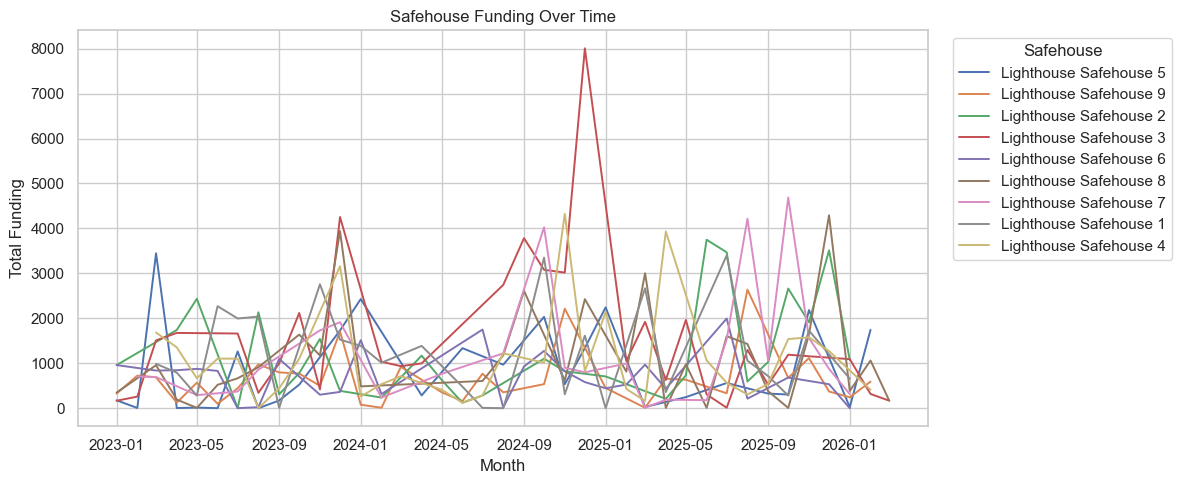

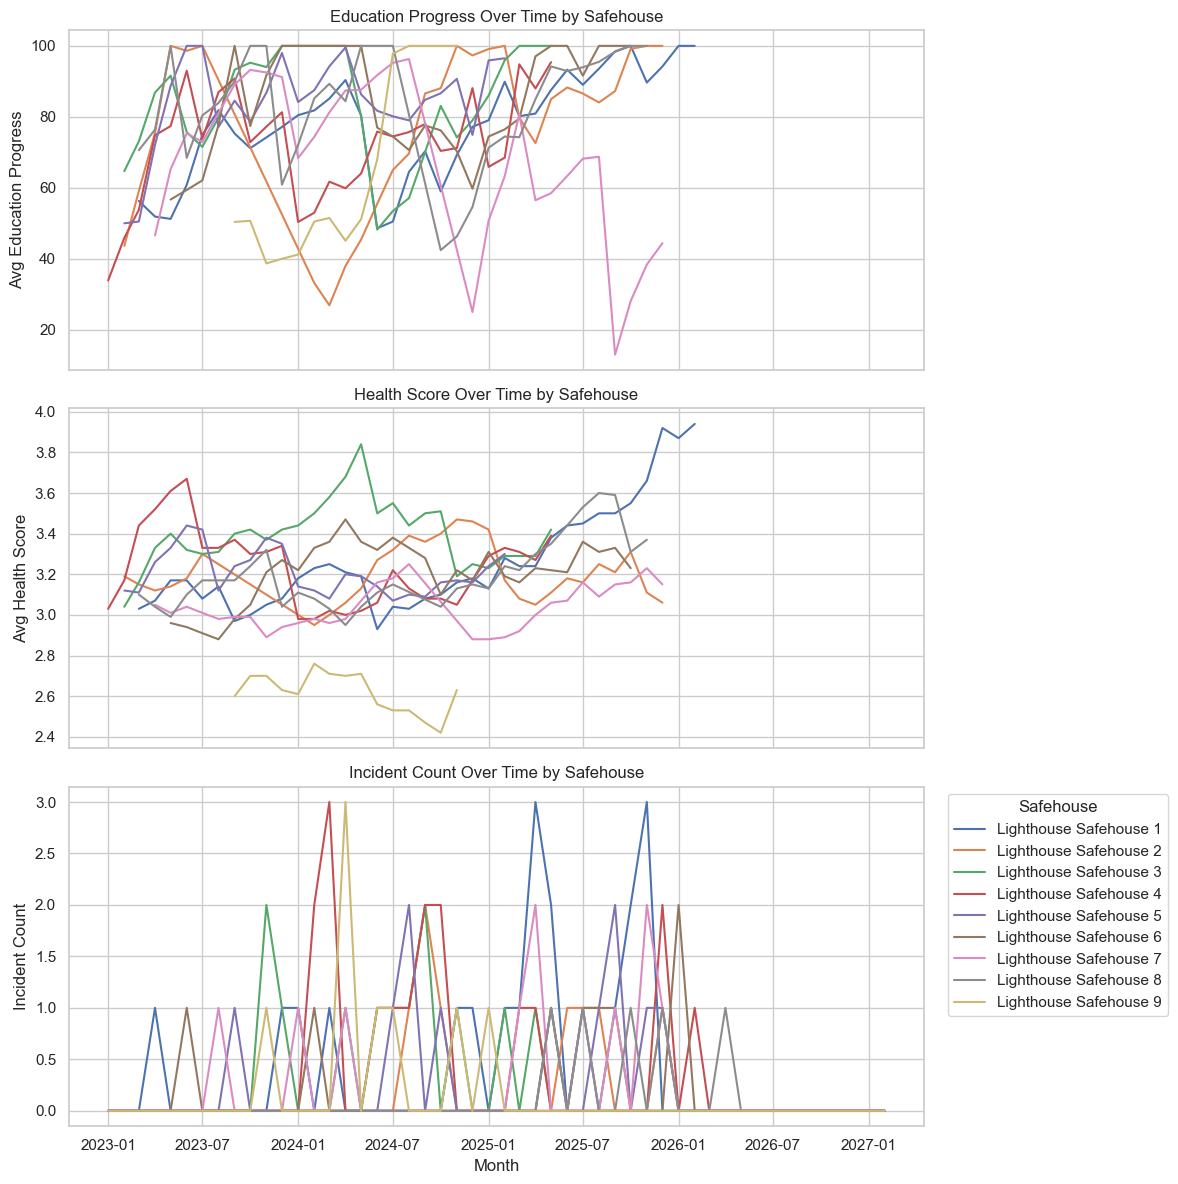

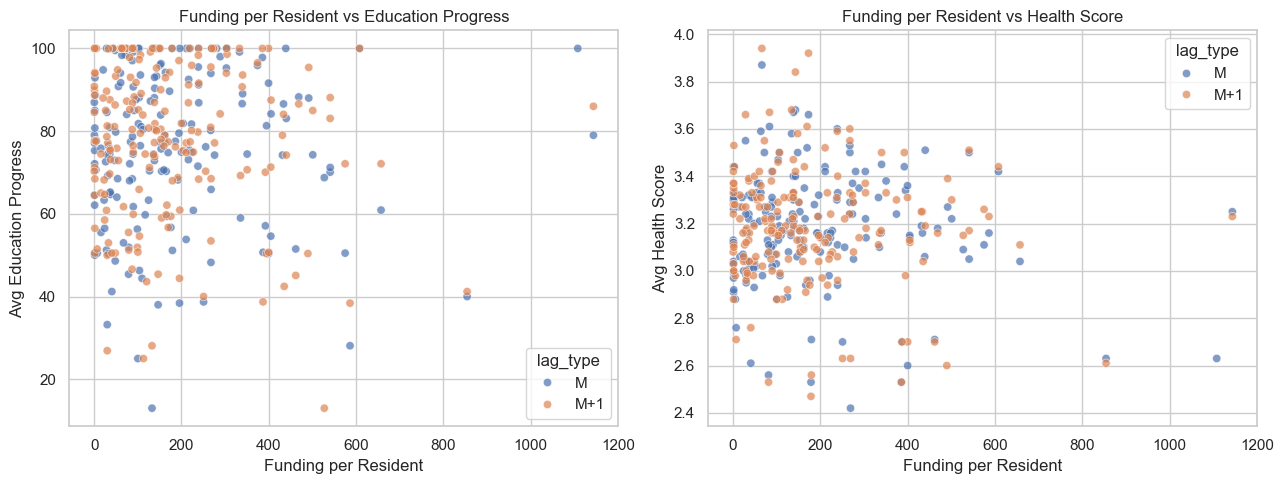

In [9]:
# Time-series and relationship visualizations

funding_over_time = funding_sm.merge(safehouses[["safehouse_id", "name"]], on="safehouse_id", how="left")
plt.figure(figsize=(12, 5))
sns.lineplot(data=funding_over_time.sort_values("allocation_month"), x="allocation_month", y="total_funding", hue="name", linewidth=1.4)
plt.title("Safehouse Funding Over Time")
plt.xlabel("Month")
plt.ylabel("Total Funding")
plt.legend(title="Safehouse", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

metrics_plot = safehouse_metrics.merge(safehouses[["safehouse_id", "name"]], on="safehouse_id", how="left")
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
sns.lineplot(data=metrics_plot, x="month_start", y="avg_education_progress", hue="name", ax=axes[0], legend=False)
axes[0].set_title("Education Progress Over Time by Safehouse")
axes[0].set_ylabel("Avg Education Progress")

sns.lineplot(data=metrics_plot, x="month_start", y="avg_health_score", hue="name", ax=axes[1], legend=False)
axes[1].set_title("Health Score Over Time by Safehouse")
axes[1].set_ylabel("Avg Health Score")

sns.lineplot(data=metrics_plot, x="month_start", y="incident_count", hue="name", ax=axes[2])
axes[2].set_title("Incident Count Over Time by Safehouse")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Incident Count")
axes[2].legend(title="Safehouse", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plot_df = table_a.dropna(subset=["funding_per_resident", "avg_education_progress", "avg_health_score"])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=plot_df, x="funding_per_resident", y="avg_education_progress", hue="lag_type", alpha=0.7, ax=axes[0])
axes[0].set_title("Funding per Resident vs Education Progress")
axes[0].set_xlabel("Funding per Resident")
axes[0].set_ylabel("Avg Education Progress")

sns.scatterplot(data=plot_df, x="funding_per_resident", y="avg_health_score", hue="lag_type", alpha=0.7, ax=axes[1])
axes[1].set_title("Funding per Resident vs Health Score")
axes[1].set_xlabel("Funding per Resident")
axes[1].set_ylabel("Avg Health Score")
plt.tight_layout()
plt.show()

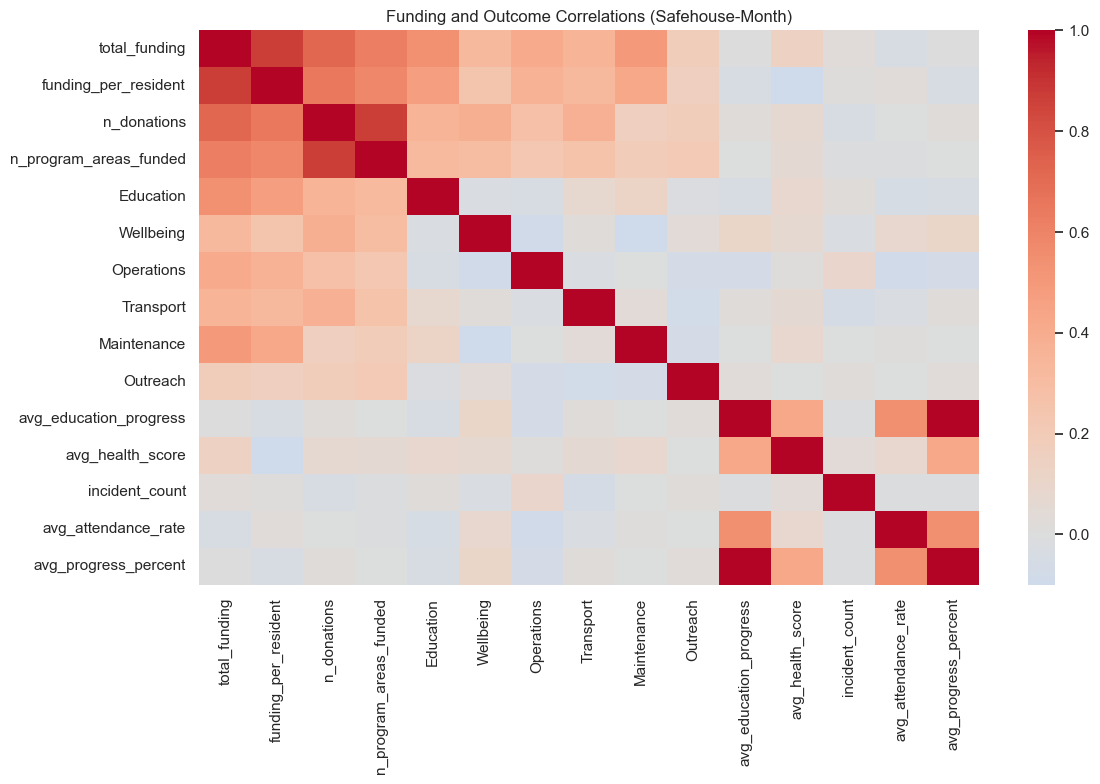

Key correlation ranges (funding vars vs outcomes):

avg_education_progress
 Operations             -0.063664
funding_per_resident   -0.042780
Education              -0.036303
total_funding           0.006285
Wellbeing               0.108591
Name: avg_education_progress, dtype: float64

avg_health_score
 funding_per_resident   -0.096775
Operations              0.015953
Wellbeing               0.063922
Education               0.088053
total_funding           0.133740
Name: avg_health_score, dtype: float64

incident_count
 Wellbeing              -0.028723
funding_per_resident    0.008948
Education               0.022812
total_funding           0.032270
Operations              0.094963
Name: incident_count, dtype: float64

avg_attendance_rate
 Operations             -0.088238
Education              -0.049553
total_funding          -0.036703
funding_per_resident    0.025455
Wellbeing               0.081095
Name: avg_attendance_rate, dtype: float64

Interpretation: correlations are generally

In [10]:
# Correlation analysis (expected weak)

corr_cols = [
    "total_funding", "funding_per_resident", "n_donations", "n_program_areas_funded",
    "Education", "Wellbeing", "Operations", "Transport", "Maintenance", "Outreach",
    "avg_education_progress", "avg_health_score", "incident_count", "avg_attendance_rate", "avg_progress_percent"
]

corr_df = table_a[corr_cols].dropna()
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Funding and Outcome Correlations (Safehouse-Month)")
plt.tight_layout()
plt.show()

print("Key correlation ranges (funding vars vs outcomes):")
for outcome in ["avg_education_progress", "avg_health_score", "incident_count", "avg_attendance_rate"]:
    rel = corr.loc[["total_funding", "funding_per_resident", "Education", "Wellbeing", "Operations"], outcome].sort_values()
    print(f"\n{outcome}\n", rel)

print("\nInterpretation: correlations are generally weak-to-modest, which is expected for this indirect funding-to-outcome chain and small sample sizes.")

In [11]:
# Campaign-level analysis

campaign_alloc = allocation_base.copy()
campaign_alloc["campaign_name"] = campaign_alloc["campaign_name"].fillna("Unspecified")
campaign_alloc["allocation_month"] = campaign_alloc["allocation_month"].dt.to_period("M").dt.to_timestamp()

campaign_metrics = campaign_alloc.merge(
    safehouse_metrics[["safehouse_id", "metrics_month", "avg_education_progress", "avg_health_score", "incident_count", "active_residents"]]
    .rename(columns={"metrics_month": "allocation_month"}),
    on=["safehouse_id", "allocation_month"],
    how="left"
)

campaign_summary = (
    campaign_metrics[campaign_metrics["campaign_name"].isin(["Year-End Hope", "Back to School", "Summer of Safety", "GivingTuesday"])]
    .groupby("campaign_name", as_index=False)
    .agg(total_raised=("amount_allocated", "sum"),
         donor_count=("supporter_id", "nunique"),
         safehouses_funded=("safehouse_id", "nunique"),
         avg_education_progress=("avg_education_progress", "mean"),
         avg_health_score=("avg_health_score", "mean"),
         avg_incident_count=("incident_count", "mean"),
         residents_supported=("active_residents", "sum"))
    .sort_values("total_raised", ascending=False)
)

campaign_program_breakdown = (
    campaign_alloc[campaign_alloc["campaign_name"].isin(["Year-End Hope", "Back to School", "Summer of Safety", "GivingTuesday"])]
    .pivot_table(index="campaign_name", columns="program_area", values="amount_allocated", aggfunc="sum", fill_value=0)
)

print(campaign_summary)
print("\nProgram area allocation by campaign:")
display(campaign_program_breakdown)

      campaign_name  total_raised  donor_count  safehouses_funded  avg_education_progress  avg_health_score  avg_incident_count  \
3     Year-End Hope      43884.04           34                  9               78.010625          3.164531            0.486842   
0    Back to School      23492.38           27                  9               76.436571          3.228857            0.317073   
2  Summer of Safety      21051.93           22                  9               78.925405          3.194865            0.166667   
1     GivingTuesday      13253.31           16                  9               83.794118          3.184706            0.347826   

   residents_supported  
3                  515  
0                  287  
2                  294  
1                  165  

Program area allocation by campaign:


program_area,Education,Maintenance,Operations,Outreach,Transport,Wellbeing
campaign_name,,,,,,
Back to School,5945.50,1094.99,7569.70,2745.84,3273.38,2862.97
GivingTuesday,3384.76,0.00,5418.65,3111.08,337.38,1001.44
Summer of Safety,2728.99,3597.72,4790.25,1368.62,2501.59,6064.76
Year-End Hope,6792.55,8646.95,11424.93,2118.22,7793.23,7108.16


# Section 3: Modeling & Feature Selection

The primary model is explanatory: do funding variables at the safehouse-month level correlate with outcomes, after controlling for safehouse context and seasonality? We fit simple OLS models for three outcomes.

We also build reusable storytelling functions (the core product deliverable) and a lightweight allocation-pattern model for donation-page projections.

In [12]:
# Explanatory regressions with controls (safehouse fixed effects + month seasonality)

model_df = table_a.copy()
model_df = model_df.dropna(subset=["avg_education_progress", "avg_health_score", "incident_count", "funding_per_resident", "active_residents"])
model_df["month_num"] = model_df["allocation_month"].dt.month.astype("category")

f_edu = "avg_education_progress ~ funding_per_resident + Education + Wellbeing + Operations + Transport + Maintenance + Outreach + active_residents + C(safehouse_id) + C(month_num)"
f_health = "avg_health_score ~ funding_per_resident + Education + Wellbeing + Operations + Transport + Maintenance + Outreach + active_residents + C(safehouse_id) + C(month_num)"
f_inc = "incident_count ~ funding_per_resident + Education + Wellbeing + Operations + Transport + Maintenance + Outreach + active_residents + C(safehouse_id) + C(month_num)"

m_edu = smf.ols(f_edu, data=model_df).fit()
m_health = smf.ols(f_health, data=model_df).fit()
m_inc = smf.ols(f_inc, data=model_df).fit()

print("Education model R^2:", round(m_edu.rsquared, 4), "Adj R^2:", round(m_edu.rsquared_adj, 4))
print("Health model R^2:", round(m_health.rsquared, 4), "Adj R^2:", round(m_health.rsquared_adj, 4))
print("Incident model R^2:", round(m_inc.rsquared, 4), "Adj R^2:", round(m_inc.rsquared_adj, 4))

coef_table = pd.DataFrame({
    "education_coef": m_edu.params,
    "education_p": m_edu.pvalues,
    "health_coef": m_health.params,
    "health_p": m_health.pvalues,
    "incident_coef": m_inc.params,
    "incident_p": m_inc.pvalues,
})

display(coef_table.loc[[c for c in coef_table.index if c in ["funding_per_resident", "Education", "Wellbeing", "Operations", "Transport", "Maintenance", "Outreach", "active_residents"]]])

Education model R^2: 0.192 Adj R^2: 0.1316
Health model R^2: 0.539 Adj R^2: 0.5046
Incident model R^2: 0.1328 Adj R^2: 0.068


,education_coef,education_p,health_coef,health_p,incident_coef,incident_p
funding_per_resident,-0.012091,4.579839e-01,-0.000027,8.606527e-01,0.000288,0.625894
Education,-0.000695,8.057452e-01,0.000008,7.672872e-01,-0.000033,0.748277
Wellbeing,0.005070,9.209920e-02,-0.000002,9.409742e-01,-0.000081,0.457842
Operations,0.000096,9.733314e-01,0.000005,8.514045e-01,0.000036,0.729423
Transport,0.001451,6.879055e-01,-0.000004,9.029851e-01,-0.000117,0.373964
Maintenance,0.001680,5.495122e-01,0.000006,8.286823e-01,-0.000063,0.538456
Outreach,0.000532,8.894438e-01,-0.000034,3.544544e-01,0.000027,0.847942
active_residents,2.884011,7.434531e-08,0.153684,1.755269e-100,0.056204,0.003367


In [13]:
# Lightweight predictive allocation model from historical proportions

alloc_for_pred = allocation_base.groupby(["donation_id", "program_area"], as_index=False)["amount_allocated"].sum()
donation_totals = alloc_for_pred.groupby("donation_id", as_index=False)["amount_allocated"].sum().rename(columns={"amount_allocated": "donation_total"})
alloc_for_pred = alloc_for_pred.merge(donation_totals, on="donation_id", how="left")
alloc_for_pred["actual_share"] = alloc_for_pred["amount_allocated"] / alloc_for_pred["donation_total"]

wide_actual = alloc_for_pred.pivot_table(index="donation_id", columns="program_area", values="actual_share", fill_value=0)
for p in PROGRAM_AREAS:
    if p not in wide_actual.columns:
        wide_actual[p] = 0
wide_actual = wide_actual[PROGRAM_AREAS]

train_ids, test_ids = train_test_split(wide_actual.index, test_size=0.25, random_state=42)
train_avg_share = wide_actual.loc[train_ids].mean()
pred_test = pd.DataFrame(np.tile(train_avg_share.values, (len(test_ids), 1)), index=test_ids, columns=PROGRAM_AREAS)

allocation_mae = mean_absolute_error(wide_actual.loc[test_ids].values.flatten(), pred_test.values.flatten())
print("Allocation share MAE (lower is better):", round(allocation_mae, 4))

comparison = pd.DataFrame({
    "actual_mean_share": wide_actual.loc[test_ids].mean(),
    "predicted_mean_share": pred_test.mean()
})
display(comparison)

Allocation share MAE (lower is better): 0.2617


,actual_mean_share,predicted_mean_share
Education,0.242857,0.199661
Wellbeing,0.209524,0.195814
Operations,0.221790,0.246705
Transport,0.125830,0.157816
Maintenance,0.109523,0.100000
Outreach,0.090476,0.100003


In [14]:
# Storytelling engine functions (primary deliverable)

def _php(x):
    return f"\u20b1{x:,.0f}"

# Helper references
safehouse_perf = (
    table_a.groupby(["safehouse_id", "name"], as_index=False)
    .agg(avg_education_progress=("avg_education_progress", "mean"),
         avg_health_score=("avg_health_score", "mean"),
         avg_attendance_rate=("avg_attendance_rate", "mean"),
         typical_active_residents=("active_residents", "mean"))
)

residents_per_php = (table_a["active_residents"].sum() / table_a["total_funding"].sum()) if table_a["total_funding"].sum() > 0 else 0
avg_funding_per_resident_month = table_a["funding_per_resident"].dropna().mean()


def donation_impact_story(donation_id) -> dict:
    """Given a donation, return a narrative about its impact."""
    rows = table_b[table_b["donation_id"] == donation_id].copy()
    if rows.empty:
        return {"error": "Donation not found"}

    amount = rows["amount"].dropna().iloc[0] if rows["amount"].notna().any() else rows["estimated_value"].iloc[0]
    safehouse_count = rows["safehouse_id"].nunique()
    residents_served = rows["active_residents_same"].fillna(rows["active_residents_lag1"]).sum()
    edu_score = rows["avg_education_progress_same"].fillna(rows["avg_education_progress_lag1"]).mean()
    programs = rows.groupby("program_area")["amount_allocated"].sum().sort_values(ascending=False)
    top_safehouse = rows.groupby("name")["amount_allocated"].sum().sort_values(ascending=False).index[0]

    projected_months_per_person_funded = (
        float(amount / avg_funding_per_resident_month)
        if pd.notna(avg_funding_per_resident_month) and avg_funding_per_resident_month > 0
        else None
    )

    months_text = (
        f"{projected_months_per_person_funded:.2f} month(s)"
        if projected_months_per_person_funded is not None
        else "an unavailable number of months"
    )

    narrative = (
        f"Your {_php(amount)} was allocated across {safehouse_count} safehouse(s), with strongest support to "
        f"{programs.index[0]} at {top_safehouse}. During the funded period, these safehouses served about "
        f"{int(round(residents_served))} active residents and averaged {edu_score:.1f}% education progress. "
        f"Based on historical funding intensity, this is roughly {months_text} of support for one resident."
    )

    return {
        "donation_id": int(donation_id),
        "amount": float(amount),
        "program_areas_funded": programs.to_dict(),
        "safehouses_reached": int(safehouse_count),
        "residents_served_est": float(residents_served),
        "avg_education_progress": float(edu_score) if pd.notna(edu_score) else None,
        "projected_months_per_person_funded": projected_months_per_person_funded,
        "narrative": narrative,
    }


def supporter_impact_story(supporter_id) -> dict:
    """Aggregate all donations from one supporter into one impact story."""
    rows = table_b[table_b["supporter_id"] == supporter_id].copy()
    if rows.empty:
        return {"error": "Supporter not found or has no linked allocations"}

    supporter_donations = donations[donations["supporter_id"] == supporter_id].copy()
    if supporter_donations.empty:
        return {"error": "Supporter has no donations"}

    donation_values = supporter_donations["amount"].fillna(supporter_donations["estimated_value"])
    total_contributed = float(donation_values.fillna(0).sum())
    donation_count = int(supporter_donations["donation_id"].nunique())

    safehouse_count = int(rows["safehouse_id"].nunique())
    programs = rows.groupby("program_area")["amount_allocated"].sum().sort_values(ascending=False)
    top_safehouse = rows.groupby("name")["amount_allocated"].sum().sort_values(ascending=False).index[0]

    residents_est_per_link = rows["active_residents_same"].fillna(rows["active_residents_lag1"])
    residents_served = float(
        rows.assign(_res_est=residents_est_per_link)
            .groupby(["donation_id", "safehouse_id"], as_index=False)["_res_est"]
            .max()["_res_est"]
            .fillna(0)
            .sum()
    )

    edu_score = rows["avg_education_progress_same"].fillna(rows["avg_education_progress_lag1"]).mean()
    avg_health = rows["avg_health_score_same"].fillna(rows["avg_health_score_lag1"]).mean()

    projected_months_per_person_funded = (
        float(total_contributed / avg_funding_per_resident_month)
        if pd.notna(avg_funding_per_resident_month) and avg_funding_per_resident_month > 0
        else None
    )

    first_date = supporter_donations["donation_date"].min()
    last_date = supporter_donations["donation_date"].max()
    months_text = (
        f"{projected_months_per_person_funded:.2f} month(s)"
        if projected_months_per_person_funded is not None
        else "an unavailable number of months"
    )

    narrative = (
        f"Across {donation_count} donation(s) from {first_date.date()} to {last_date.date()}, this supporter contributed "
        f"{_php(total_contributed)} across {safehouse_count} safehouse(s), with strongest support to {programs.index[0]} "
        f"at {top_safehouse}. These funded safehouses served about {int(round(residents_served))} resident-months and "
        f"averaged {edu_score:.1f}% education progress and {avg_health:.2f} health score. Based on historical funding intensity, "
        f"this is roughly {months_text} of support for one resident."
    )

    return {
        "supporter_id": int(supporter_id),
        "donation_count": donation_count,
        "total_contributed": total_contributed,
        "program_areas_funded": programs.to_dict(),
        "safehouses_reached": safehouse_count,
        "residents_served_est": residents_served,
        "avg_education_progress": float(edu_score) if pd.notna(edu_score) else None,
        "avg_health_score": float(avg_health) if pd.notna(avg_health) else None,
        "projected_months_per_person_funded": projected_months_per_person_funded,
        "date_range": {
            "start": str(first_date.date()) if pd.notna(first_date) else None,
            "end": str(last_date.date()) if pd.notna(last_date) else None,
        },
        "narrative": narrative,
    }


def campaign_impact_summary(campaign_name) -> dict:
    """Summarize a campaign's total impact."""
    c = campaign_metrics[campaign_metrics["campaign_name"] == campaign_name].copy()
    if c.empty:
        return {"error": "Campaign not found"}

    total_raised = c["amount_allocated"].sum()
    donor_count = c["supporter_id"].nunique()
    safehouses_funded = c["safehouse_id"].nunique()
    residents_served = c["active_residents"].sum()
    avg_edu = c["avg_education_progress"].mean()
    avg_health = c["avg_health_score"].mean()
    breakdown = c.groupby("program_area")["amount_allocated"].sum().sort_values(ascending=False).to_dict()

    narrative = (
        f"{campaign_name} raised {_php(total_raised)} from {donor_count} donors, funding {safehouses_funded} safehouses "
        f"that collectively supported about {int(round(residents_served))} resident-months with average outcomes of "
        f"{avg_edu:.1f}% education progress and {avg_health:.2f} health score."
    )

    return {
        "campaign_name": campaign_name,
        "total_raised": float(total_raised),
        "donor_count": int(donor_count),
        "safehouses_funded": int(safehouses_funded),
        "residents_served": float(residents_served),
        "avg_education_progress": float(avg_edu) if pd.notna(avg_edu) else None,
        "avg_health_score": float(avg_health) if pd.notna(avg_health) else None,
        "program_breakdown": breakdown,
        "narrative": narrative,
    }


def projected_impact(amount_php, program_area=None) -> dict:
    """For donation page: estimate likely support using historical averages."""
    shares = train_avg_share.copy()
    if program_area in PROGRAM_AREAS:
        shares = pd.Series(0, index=PROGRAM_AREAS, dtype=float)
        shares[program_area] = 1.0

    allocation_projection = (shares * amount_php).to_dict()

    # pick historically common safehouses by funded amount
    house_weights = allocations.groupby("safehouse_id")["amount_allocated"].sum()
    house_weights = house_weights / house_weights.sum()
    top_house = int(house_weights.sort_values(ascending=False).index[0])
    top_house_name = safehouses.loc[safehouses["safehouse_id"].eq(top_house), "name"].iloc[0]

    typical = safehouse_perf[safehouse_perf["safehouse_id"] == top_house].iloc[0]
    residents_supported = amount_php * residents_per_php

    narrative = (
        f"If you donate {_php(amount_php)} today, it would most likely be allocated across programs like "
        f"{', '.join([f'{k} ({v*100:.0f}%)' for k, v in shares.sort_values(ascending=False).head(3).items()])}. "
        f"Based on historical patterns, this could support about {residents_supported:.1f} resident-months, often in "
        f"safehouses such as {top_house_name}, where typical outcomes include {typical['avg_education_progress']:.1f}% education progress "
        f"and {typical['avg_health_score']:.2f} health score."
    )

    return {
        "amount_php": float(amount_php),
        "program_breakdown": allocation_projection,
        "likely_safehouse": top_house_name,
        "projected_resident_months": float(residents_supported),
        "typical_outcomes": {
            "avg_education_progress": float(typical["avg_education_progress"]),
            "avg_health_score": float(typical["avg_health_score"]),
            "avg_attendance_rate": float(typical["avg_attendance_rate"]) if pd.notna(typical["avg_attendance_rate"]) else None,
        },
        "narrative": narrative,
    }


def time_period_summary(start_date, end_date) -> dict:
    """Quarterly or annual impact summary for donor reports."""
    s = pd.to_datetime(start_date)
    e = pd.to_datetime(end_date)

    d = donations[(donations["donation_date"] >= s) & (donations["donation_date"] <= e)]
    a = allocation_base[(allocation_base["allocation_date"] >= s) & (allocation_base["allocation_date"] <= e)]

    safehouse_ids = a["safehouse_id"].unique().tolist()
    m = safehouse_metrics[(safehouse_metrics["month_start"] >= s) & (safehouse_metrics["month_start"] <= e) & (safehouse_metrics["safehouse_id"].isin(safehouse_ids))]

    narrative = (
        f"From {s.date()} to {e.date()}, total donations of {_php(d['amount'].fillna(0).sum())} supported "
        f"{a['safehouse_id'].nunique()} safehouses and {int(m['active_residents'].sum())} resident-months. "
        f"Average tracked outcomes in funded safehouses were {m['avg_education_progress'].mean():.1f}% education progress and "
        f"{m['avg_health_score'].mean():.2f} health score."
    )

    return {
        "start_date": str(s.date()),
        "end_date": str(e.date()),
        "total_donations": float(d["amount"].fillna(0).sum()),
        "n_donations": int(d["donation_id"].nunique()),
        "safehouses_supported": int(a["safehouse_id"].nunique()),
        "resident_months": float(m["active_residents"].sum()),
        "avg_education_progress": float(m["avg_education_progress"].mean()) if not m.empty else None,
        "avg_health_score": float(m["avg_health_score"].mean()) if not m.empty else None,
        "narrative": narrative,
    }

# Section 4: Evaluation & Interpretation

We evaluate three outputs: (1) explanatory model fit and coefficient significance, (2) narrative quality with concrete examples, and (3) projected-allocation accuracy on a held-out donation set.

Interpretation principle: conservative and verifiable claims only. Weak model fit is expected and should be reported transparently.

In [15]:
# Evaluation outputs and examples

print("Explanatory model interpretation:")
print(f"- Education model explains about {m_edu.rsquared*100:.1f}% of variance from funding + controls.")
print(f"- Health model explains about {m_health.rsquared*100:.1f}% of variance.")
print(f"- Incident model explains about {m_inc.rsquared*100:.1f}% of variance.")
print("- Weak explanatory power is expected: funding is necessary but not sufficient for outcomes.")

print("\nStorytelling examples:")
example_donation = int(table_b["donation_id"].iloc[0])
print("\n1) Per-donation")
print(donation_impact_story(example_donation)["narrative"])

print("\n2) Per-campaign")
print(campaign_impact_summary("Year-End Hope")["narrative"])

print("\n3) Per-program projection")
print(projected_impact(1000)["narrative"])

print("\n4) Per-time-period")
print(time_period_summary("2024-07-01", "2024-09-30")["narrative"])

print("\nDonation page sample narrative:")
print(projected_impact(1000, program_area="Education")["narrative"])

print("\nQuarterly donor report paragraph sample:")
print(time_period_summary("2024-01-01", "2024-03-31")["narrative"])

print("\nAllocation projection metric:")
print(f"Held-out allocation share MAE: {allocation_mae:.4f}")

print("\nFP/FN-style risk framing:")
print("- False positive equivalent: overstating impact beyond data support erodes donor trust.")
print("- False negative equivalent: understating impact misses retention opportunities.")
print("- Pipeline policy: prioritize conservative, traceable, and auditable statements.")

Explanatory model interpretation:
- Education model explains about 19.2% of variance from funding + controls.
- Health model explains about 53.9% of variance.
- Incident model explains about 13.3% of variance.
- Weak explanatory power is expected: funding is necessary but not sufficient for outcomes.

Storytelling examples:

1) Per-donation
Your ₱717 was allocated across 1 safehouse(s), with strongest support to Education at Lighthouse Safehouse 2. During the funded period, these safehouses served about 8 active residents and averaged 100.0% education progress. Based on historical funding intensity, this is roughly 3.93 month(s) of support for one resident.

2) Per-campaign
Year-End Hope raised ₱43,884 from 34 donors, funding 9 safehouses that collectively supported about 515 resident-months with average outcomes of 78.0% education progress and 3.16 health score.

3) Per-program projection
If you donate ₱1,000 today, it would most likely be allocated across programs like Operations (25

# Section 5: Causal and Relationship Analysis

Correlation does not imply causation in this pipeline. Safehouses receiving more funds may differ systematically in resident profile, staffing quality, intervention maturity, or local context. The explanatory model quantifies associations only.

Confounders include case mix (e.g., share of high-risk or trafficked residents), staffing and therapeutic quality, safehouse age, partner support, and regional conditions. Aggregate correlations can also create ecological fallacy: a safehouse-level pattern may not hold for any individual resident.

To make stronger causal claims, the organization would need designs such as randomized funding allocation (not feasible in practice) or quasi-experimental approaches (e.g., clear funding shocks with difference-in-differences). The honest and useful claim here is: we can reliably show where money went and what outcomes occurred in those funded contexts, without claiming donations alone caused those outcomes.

In [16]:
# Funding feature importances (absolute coefficient ranking from education model)

importance = (
    coef_table.loc[["funding_per_resident", "Education", "Wellbeing", "Operations", "Transport", "Maintenance", "Outreach"], ["education_coef", "health_coef", "incident_coef"]]
    .assign(abs_education=lambda d: d["education_coef"].abs())
    .sort_values("abs_education", ascending=False)
)

display(importance)
print("These are association strengths from linear models, not causal effects.")

,education_coef,health_coef,incident_coef,abs_education
funding_per_resident,-0.012091,-0.000027,0.000288,0.012091
Wellbeing,0.005070,-0.000002,-0.000081,0.005070
Maintenance,0.001680,0.000006,-0.000063,0.001680
Transport,0.001451,-0.000004,-0.000117,0.001451
Education,-0.000695,0.000008,-0.000033,0.000695
Outreach,0.000532,-0.000034,0.000027,0.000532
Operations,0.000096,0.000005,0.000036,0.000096


These are association strengths from linear models, not causal effects.


# Section 6: Deployment Notes

This pipeline has **two separate deployed artifacts** because it serves two distinct use cases: real-time OLS predictions and donor-facing storytelling. They run in separate containers.

---

## 6A: Main ML API — OLS Prediction Endpoint

**Artifact:** `models/donation_impact_pipeline.joblib`

This joblib file stores the OLS model parameter dicts (education, health, incident) as plain Python dictionaries, plus lookup tables (allocation average shares, safehouse performance, residents-per-PHP). It is loaded by the main FastAPI ML API (`app/main.py`) at startup alongside all other model artifacts.

**Endpoints on the main ML API** (`harboredhope-ml-api.azurewebsites.net`):

```
POST /predict/donation/impact
```
Accepts a JSON body with `funding_per_resident`, `active_residents`, and PHP amounts per program area (Education, Wellbeing, Operations, Transport, Maintenance, Outreach), plus optional `safehouse_id` and `month_num` for fixed effects. Returns predicted `avg_education_progress`, `avg_health_score`, and `incident_count` from the three OLS models.

```
GET /donation/impact/context
```
Returns the static storytelling lookup tables (average allocation shares, residents-per-PHP scalar, safehouse performance averages, generated_at timestamp) — no input required. Called once at page load by the donor dashboard.

---

## 6B: Standalone Storytelling Service

**Artifact:** `models/donation_impact_pipeline.sav`

This is a separate, richer pickle artifact (artifact_version=2) that stores the full DataFrames needed for per-donation, per-supporter, per-campaign, and time-period narrative generation. It is too large to serve from the main API and requires `DonationImpactStorytelling` class methods that operate on those DataFrames.

**Service:** `donation_impact_api.py` + `donation_impact_storytelling.py` — deployed as a separate Azure App Service container using `Dockerfile.storytelling`.

**Endpoints on the storytelling service** (`lighthouse-storytelling.azurewebsites.net`):

```
GET  /api/donation-impact/{donation_id}      → narrative for a specific donation
GET  /api/supporter-impact/{supporter_id}    → lifetime impact story for a supporter
GET  /api/campaign-impact?campaign_name=     → campaign-level aggregate summary
POST /api/projected-impact                   → "what would ₱X do?" forward-looking projection
GET  /api/time-period-summary?start=&end=    → date-range aggregate for donor reports
```

All responses include a pre-written `narrative` string ready to render directly in the UI.

---

## 6C: Integration Architecture

```
React donor dashboard
      ↓
.NET Web API (HarboredHope.API)
      ├── calls GET /donation/impact/context   → main ML API (page load)
      ├── calls POST /predict/donation/impact  → main ML API (OLS prediction)
      └── calls GET /api/supporter-impact/{id} → storytelling service (donor page)
```

The .NET backend proxies all calls — the browser never talks to the Python services directly. This keeps auth, CORS, and rate limiting in one place.

---

## 6D: Deployment Commands

```bash
# Main ML API (includes donation_impact_pipeline.joblib)
docker buildx build --platform linux/amd64 -t harboredhoperegistry.azurecr.io/lighthouse-ml-api:latest --push .

# Storytelling service (includes donation_impact_pipeline.sav)
docker buildx build --platform linux/amd64 -f Dockerfile.storytelling \
  -t harboredhoperegistry.azurecr.io/lighthouse-storytelling:latest --push .
```

In [17]:
# Save pipeline artifacts (v2: full tables for donation_impact_storytelling.py + API)

artifacts = {
    "artifact_version": 2,
    "program_areas": PROGRAM_AREAS,
    "table_b": table_b,
    "donations": donations,
    "campaign_metrics": campaign_metrics,
    "allocation_base": allocation_base,
    "allocations": allocations,
    "safehouses": safehouses,
    "safehouse_metrics": safehouse_metrics,
    "train_avg_share": train_avg_share,
    "safehouse_perf": safehouse_perf,
    "residents_per_php": residents_per_php,
    "avg_funding_per_resident_month": avg_funding_per_resident_month,
    "allocation_average_shares": train_avg_share.to_dict(),
    "safehouse_performance": safehouse_perf,
    "education_model_params": m_edu.params.to_dict(),
    "health_model_params": m_health.params.to_dict(),
    "incident_model_params": m_inc.params.to_dict(),
    "allocation_share_mae": allocation_mae,
    "generated_at": datetime.utcnow().isoformat(),
}

with open(MODEL_PATH, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved artifacts to {MODEL_PATH.resolve()}")

Saved artifacts to /Users/jigby5/Downloads/lighthouse_csv_v7/donation_impact_pipeline.sav


# Section 7: Recommendations & Decisions

1. **Communicate impact conservatively and verifiably.** Use phrasing such as: "Your donation funded [program area] at [safehouse], where [X girls] recorded [Y outcomes] during that period." Avoid claiming direct causal improvement from a single donation.
2. **Use campaign summaries as a primary storytelling asset.** Campaign-level aggregation is richer and more stable than single-donation inference, making it ideal for donor updates and landing pages.
3. **Strengthen future analysis with better linkage data.** Prioritize collecting per-resident funding exposure, staff-hours per resident, intervention dosage, and program cost tracking.
4. **Use explanatory metrics as transparency tools, not proof of effect.** Weak or null coefficients should be reported openly to protect trust.
5. **Operational decision:** do not publish statements like "your donation improved outcomes by X%." Publish traceable funding-and-context statements instead.

This notebook intentionally shows that when causality is weak, high-integrity aggregation and narrative generation are still valuable ML/data products.

## Storytelling Function Demo Outputs

This section prints one example payload from each storytelling function so screenshots and donor-facing demos are easy to produce.

In [18]:
# Demo: sample return payloads for all storytelling functions

import json

sample_donation_id = int(table_b["donation_id"].dropna().iloc[0])
preferred_campaigns = ["Year-End Hope", "Back to School", "Summer of Safety", "GivingTuesday"]
available_campaigns = [c for c in preferred_campaigns if c in campaign_metrics["campaign_name"].dropna().unique()]
sample_campaign = available_campaigns[0] if available_campaigns else campaign_metrics["campaign_name"].dropna().iloc[0]

samples = {
    "donation_impact_story": donation_impact_story(sample_donation_id),
    "campaign_impact_summary": campaign_impact_summary(sample_campaign),
    "projected_impact": projected_impact(1000),
    "time_period_summary": time_period_summary("2024-07-01", "2024-09-30"),
}

for fn_name, payload in samples.items():
    print("\n" + "=" * 90)
    print(f"{fn_name}() sample output")
    print("=" * 90)
    print(json.dumps(payload, indent=2, default=str))


donation_impact_story() sample output
{
  "donation_id": 1,
  "amount": 717.18,
  "program_areas_funded": {
    "Education": 717.18
  },
  "safehouses_reached": 1,
  "residents_served_est": 8.0,
  "avg_education_progress": 100.0,
  "projected_months_per_person_funded": 3.9323908420123765,
  "narrative": "Your \u20b1717 was allocated across 1 safehouse(s), with strongest support to Education at Lighthouse Safehouse 2. During the funded period, these safehouses served about 8 active residents and averaged 100.0% education progress. Based on historical funding intensity, this is roughly 3.93 month(s) of support for one resident."
}

campaign_impact_summary() sample output
{
  "campaign_name": "Year-End Hope",
  "total_raised": 43884.04,
  "donor_count": 34,
  "safehouses_funded": 9,
  "residents_served": 515.0,
  "avg_education_progress": 78.01062499999999,
  "avg_health_score": 3.1645312500000005,
  "program_breakdown": {
    "Operations": 11424.93,
    "Maintenance": 8646.949999999999,

## Rubric Checklist

| Rubric requirement | Where addressed |
|---|---|
| Problem framing and stakeholders | Section 1 (Problem Framing) |
| Prediction vs. explanation distinction | Section 1 (explanatory OLS primary; lightweight allocation model secondary predictive) |
| Data loading, joins, missing values | Section 2 (4-table join: donations, allocations, safehouses, safehouse_metrics) |
| Exploration: distributions, correlations | Section 2 (visualizations, correlation analysis, campaign-level analysis) |
| Reproducible feature engineering pipeline | Section 2 (temporal alignment, Table A/B construction, program splits) |
| Feature selection with purpose | Section 3 (safehouse fixed effects + month seasonality as controls) |
| Model comparison | Section 3 (three OLS models: education, health, incident; allocation share baseline) |
| Proper validation and metrics | Section 4 (R² per model; allocation MAE on hold-out test set) |
| Business interpretation and error costs | Section 4 (Evaluation), Section 7 (Recommendations) |
| Causal/relationship analysis and limitations | Section 5 (Causal and Relationship Analysis) |
| Deployment notes / integration prep | Section 6 (two-artifact, two-service deployment) |
| Both predictive and explanatory model | OLS (explanatory); allocation share model (predictive baseline); storytelling functions (decision support) |